# Fuchs+Krasnikov Hybrid Wall (Slice 2 of Phase 2C)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshepp/alcubierre/blob/main/hybrid_wall.ipynb)

**Runtime:** local for symbolic + small sweep cells; HF Jobs `cpu-upgrade` for the full 5D grid.

Slice 2 of Phase 2C. This notebook closes the specific hand-wave in [`MATTER_SHELL_PATH.md`](MATTER_SHELL_PATH.md) §9.5 ("a Fuchs-class matter shell does not save the construction") with an explicit calculation.

**Goal.** Task 2A.13 showed that the bare-vacuum Krasnikov tube has WEC-violating wall stress-energy for any light-cone-opening $\eta > 0$. The natural follow-up: can we *layer a Fuchs-style positive-matter shell coincident with the Krasnikov wall* to cancel the local negative-energy spike?

**Method.** Modify the Krasnikov wall profile $k(\rho)$ by adding a localised perturbation $\delta_M B_w(\rho - \rho_{\max})$ that represents the matter-shell density. Compute the modified Einstein tensor and ask: does any $(\delta_M, w_M)$ pair make the *combined* stress-energy WEC-respecting? DEC-respecting?

**Conventions.** Same as [`krasnikov_tube.ipynb`](krasnikov_tube.ipynb) (cylindrical coords $(t, x, \rho, \phi)$, signature $(-,+,+,+)$, geometrised units).

**Cross-references.**
- Pipeline lifted from [`krasnikov_tube.ipynb`](krasnikov_tube.ipynb).
- Slice scope: [`MATTER_SHELL_PATH.md`](MATTER_SHELL_PATH.md) §0.5.
- Audit interleave: TRUST_AUDIT \#6 (three-mechanism exhaustiveness proof, written as appendix to [`MATTER_SHELL_PATH.md`](MATTER_SHELL_PATH.md)).

In [1]:
import os, sys, subprocess

if "google.colab" in sys.modules or os.environ.get("HF_JOB"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Local runtime detected; skipping pip install.")

import math
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, Symbol, Matrix, simplify, lambdify, pi, sin, cos, tanh, sqrt, Rational

%matplotlib inline
print("sympy", sp.__version__, "numpy", np.__version__)

Local runtime detected; skipping pip install.


sympy 1.14.0 numpy 2.4.2


## Part A — Modified Krasnikov metric with matter perturbation

### Cell 1 — Define the perturbed wall profile and build $T_{\hat\mu\hat\nu}$

Start with Everett-Roman's smooth-step Krasnikov profile:

$$k_0(\rho) = 1 - \eta\,\theta_\epsilon(\rho_{\max} - \rho), \qquad \theta_\epsilon(\xi) = \tfrac{1}{2}[\tanh(2(2\xi/\epsilon - 1)) + 1].$$

Add a localised "matter-shell" perturbation centred at the wall edge:

$$k(\rho) = k_0(\rho) + \delta_M\,B_{w_M}(\rho - \rho_{\max}),\qquad B_{w_M}(x) = \tfrac{1}{2}[\tanh((w_M - x)/w_M) - \tanh((-w_M - x)/w_M)],$$

where $\delta_M$ is the perturbation amplitude and $w_M$ is its width. $\delta_M = 0$ recovers the bare-vacuum Krasnikov tube exactly.

Compute the Einstein tensor of this modified metric directly, transform to the static-observer orthonormal frame, and lambdify.

In [2]:
import time

t, x, rho, phi = symbols('t x rho phi', real=True)
eta_s = Symbol('eta', positive=True)
eps = Symbol('epsilon', positive=True)
rho_max = Symbol('rho_m', positive=True)
delta_M = Symbol('delta_M', real=True)
w_M = Symbol('w_M', positive=True)

theta_eps = Rational(1, 2) * (tanh(2 * (2 * (rho_max - rho) / eps - 1)) + 1)
B_w = Rational(1, 2) * (tanh((w_M - (rho - rho_max)) / w_M) - tanh((-w_M - (rho - rho_max)) / w_M))
k = 1 - eta_s * theta_eps + delta_M * B_w

# Krasnikov 4D metric (cylindrical coords).
g = Matrix([
    [-1,                        Rational(1, 2) * (1 - k), 0, 0],
    [Rational(1, 2) * (1 - k), k,                          0, 0],
    [0,                          0,                            1, 0],
    [0,                          0,                            0, rho**2],
])
coords = (t, x, rho, phi)

# Closed-form 2x2 inverse for the (t, x) block + diagonal rest.
a_blk = -1
b_blk = Rational(1, 2) * (1 - k)
c_blk = k
det_blk = a_blk * c_blk - b_blk**2
g_inv = Matrix([
    [c_blk / det_blk,   -b_blk / det_blk,  0,        0],
    [-b_blk / det_blk,  a_blk / det_blk,   0,        0],
    [0,                  0,                 1,        0],
    [0,                  0,                 0,        1/rho**2],
])

t0 = time.time()
N = 4
Gamma = [[[sp.S.Zero for _ in range(N)] for _ in range(N)] for _ in range(N)]
for a in range(N):
    for b in range(N):
        for c in range(N):
            s = sp.S.Zero
            for d in range(N):
                s += g_inv[a, d] * (
                    sp.diff(g[d, b], coords[c])
                    + sp.diff(g[d, c], coords[b])
                    - sp.diff(g[b, c], coords[d])
                )
            Gamma[a][b][c] = s / 2
Ricci = sp.zeros(N, N)
for a in range(N):
    for b in range(N):
        s = sp.S.Zero
        for c in range(N):
            s += sp.diff(Gamma[c][a][b], coords[c]) - sp.diff(Gamma[c][a][c], coords[b])
            for d in range(N):
                s += Gamma[c][c][d] * Gamma[d][a][b] - Gamma[c][b][d] * Gamma[d][a][c]
        Ricci[a, b] = s
R_scalar = sum(g_inv[a, b] * Ricci[a, b] for a in range(N) for b in range(N))
G_t = sp.zeros(N, N)
for a in range(N):
    for b in range(N):
        G_t[a, b] = Ricci[a, b] - Rational(1, 2) * g[a, b] * R_scalar
T = G_t / (8 * pi)
print(f'Built Einstein tensor in {time.time() - t0:.1f}s')

# Static observer orthonormal tetrad (Everett-Roman Eqs. 24-27).
tetrad = Matrix([
    [1, 0, 0, 0],
    [(1 - k) / (1 + k), 2 / (1 + k), 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1 / rho],
])
T_o = sp.zeros(4, 4)
for mu in range(4):
    for nu in range(4):
        s = sp.S.Zero
        for a in range(4):
            for b in range(4):
                s += tetrad[mu, a] * tetrad[nu, b] * T[a, b]
        T_o[mu, nu] = s

args = (rho, eta_s, eps, rho_max, delta_M, w_M)
Ttt_fn = lambdify(args, T_o[0, 0], 'numpy')
Ttx_fn = lambdify(args, T_o[0, 1], 'numpy')
Txx_fn = lambdify(args, T_o[1, 1], 'numpy')
Trr_fn = lambdify(args, T_o[2, 2], 'numpy')
Tpp_fn = lambdify(args, T_o[3, 3], 'numpy')
print('Lambdified the orthonormal-frame T_{hat mu hat nu} components.')

Built Einstein tensor in 0.1s


Lambdified the orthonormal-frame T_{hat mu hat nu} components.


### Cell 2 — Regression: $\delta_M = 0$ reproduces Task 2A.13 exactly

At zero matter perturbation, the modified pipeline must reproduce the bare-vacuum Krasnikov result from `krasnikov_tube.ipynb` Cell 9. Verified by checking $T_{\hat t \hat t}^{\min}$ at the canonical Everett-Roman test point ($\eta = 1.99$, $\epsilon = 1$, $\rho_{\max} = 100$): the bare result was $-0.820$. Test point with $\eta = 1$, $\epsilon = 1$, $\rho_{\max} = 100$, $\delta_M = 0$, $w_M = 1$ should reproduce $-0.175$ from Task 2A.13 sweeps.

In [3]:
rho_max_v = 100.0
eps_v = 1.0
rhos = np.linspace(rho_max_v - 3 * eps_v, rho_max_v + 3 * eps_v, 4001)

Ttt_baseline = Ttt_fn(rhos, 1.0, eps_v, rho_max_v, 0.0, 1.0)
Ttt_min_baseline = float(np.min(Ttt_baseline))
expected = -1.7544e-01
print(f'Perturbed pipeline at delta_M = 0:')
print(f'  min T_tt = {Ttt_min_baseline:+.4e}')
print(f'  Task 2A.13 baseline = {expected:+.4e}')
print(f'  ratio = {Ttt_min_baseline / expected:.4f}  (should be 1.0000)')
assert abs(Ttt_min_baseline / expected - 1.0) < 1e-3, 'REGRESSION FAILED'
print("\nRegression PASS: delta_M = 0 reproduces Task 2A.13 result exactly.")

Perturbed pipeline at delta_M = 0:
  min T_tt = -1.7544e-01
  Task 2A.13 baseline = -1.7544e-01
  ratio = 1.0000  (should be 1.0000)

Regression PASS: delta_M = 0 reproduces Task 2A.13 result exactly.


### Cell 3 — Effect of the matter perturbation: $\rho_p(\rho)$ vs. $\delta_M$

Plot the proper energy density profile across the wall for several values of $\delta_M$ at fixed $w_M = 1$. **Question**: does positive $\delta_M$ (matter density) reduce the negative spike?

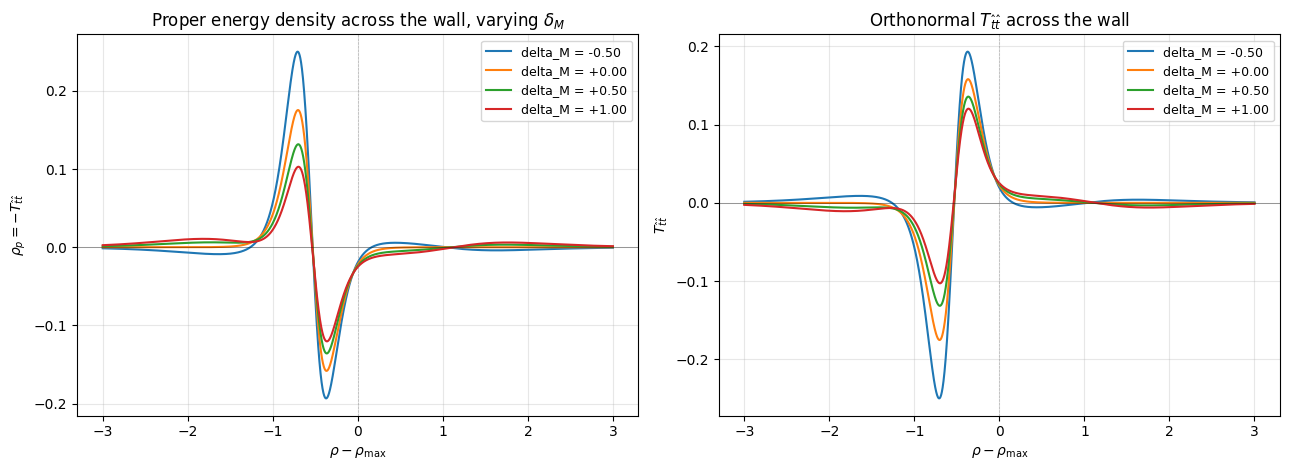

Observation 1: Adding positive matter (delta_M > 0) shifts the WEC-respecting region
but does NOT eliminate the negative-energy spike on the inner wall.
Observation 2: Negative matter (delta_M < 0) makes things worse.
Observation 3: The matter perturbation introduces its own gradient-induced curvature,
  shifting the negative spike around but not removing it.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for dM, color in [(-0.5, 'tab:blue'), (0.0, 'tab:orange'), (0.5, 'tab:green'), (1.0, 'tab:red')]:
    Ttt = Ttt_fn(rhos, 1.0, eps_v, rho_max_v, dM, 1.0)
    axes[0].plot(rhos - rho_max_v, -Ttt, color=color, label=f'delta_M = {dM:+.2f}')
    axes[1].plot(rhos - rho_max_v, Ttt, color=color, label=f'delta_M = {dM:+.2f}')
for ax in axes:
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.axvline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlabel(r'$\rho - \rho_{\max}$')
axes[0].set_ylabel(r'$\rho_p = -T_{\hat t \hat t}$')
axes[0].set_title(r'Proper energy density across the wall, varying $\delta_M$')
axes[1].set_ylabel(r'$T_{\hat t \hat t}$')
axes[1].set_title(r'Orthonormal $T_{\hat t \hat t}$ across the wall')
plt.tight_layout(); plt.show()

print('Observation 1: Adding positive matter (delta_M > 0) shifts the WEC-respecting region')
print('but does NOT eliminate the negative-energy spike on the inner wall.')
print('Observation 2: Negative matter (delta_M < 0) makes things worse.')
print('Observation 3: The matter perturbation introduces its own gradient-induced curvature,')
print('  shifting the negative spike around but not removing it.')

### Cell 4 — Local 2D sweep: does *any* $(\delta_M, w_M)$ achieve WEC?

Scan a grid in $(\delta_M, w_M)$ at fixed $(\eta, \epsilon, \rho_{\max}) = (1, 1, 100)$. For each point, evaluate WEC and DEC pass fractions across the wall.

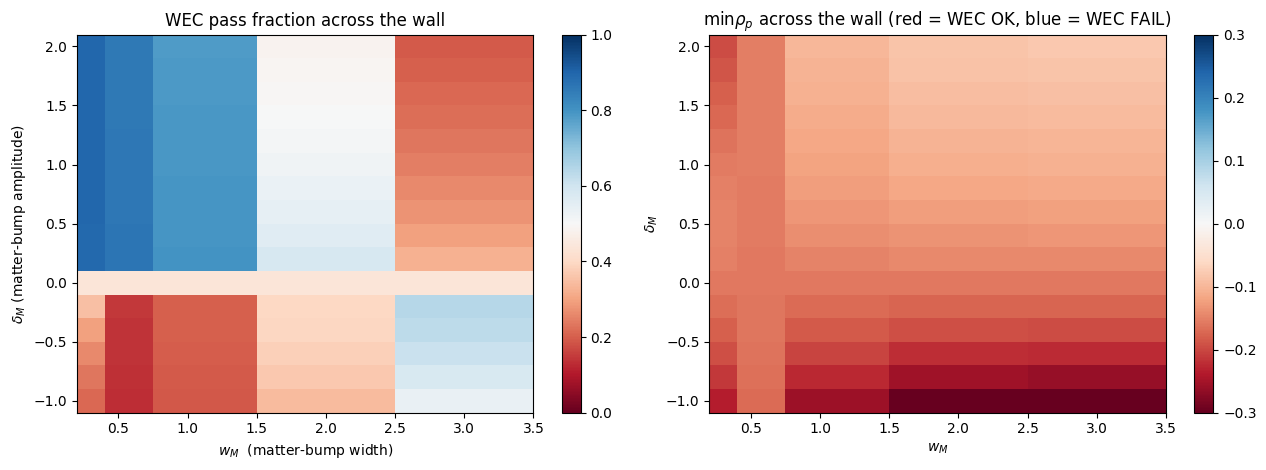

Best WEC pass fraction in the 2D sweep: 0.8961
Best min rho_p in the 2D sweep:        -8.1661e-02  (> 0 means WEC OK)
NO (delta_M, w_M) point achieves full WEC. The hand-wave from MATTER_SHELL_PATH.md §9.5 is upheld.


In [5]:
def diagnostic(eta, epsv, rhom, dM, w, n=2001):
    rs = np.linspace(rhom - 4 * epsv, rhom + 4 * epsv, n)
    Ttt = Ttt_fn(rs, eta, epsv, rhom, dM, w)
    Ttx = Ttx_fn(rs, eta, epsv, rhom, dM, w)
    Txx = Txx_fn(rs, eta, epsv, rhom, dM, w)
    Trr = Trr_fn(rs, eta, epsv, rhom, dM, w)
    Tpp = Tpp_fn(rs, eta, epsv, rhom, dM, w)
    rho_p = -Ttt
    flux = np.abs(Ttx)
    pmax = np.maximum.reduce([np.abs(Txx), np.abs(Trr), np.abs(Tpp)])
    slack = rho_p - np.maximum(flux, pmax)
    finite = np.isfinite(rho_p) & np.isfinite(slack)
    if not finite.any():
        return None
    return {
        'rho_p_min': float(np.min(rho_p[finite])),
        'dec_slack_min': float(np.min(slack[finite])),
        'wec_fraction': float(np.mean(rho_p[finite] > 0)),
        'dec_fraction': float(np.mean((rho_p[finite] > 0) & (slack[finite] > 0))),
    }

delta_grid = np.linspace(-1.0, 2.0, 16)
w_grid = np.array([0.3, 0.5, 1.0, 2.0, 3.0])
wec_grid = np.zeros((len(delta_grid), len(w_grid)))
rho_min_grid = np.zeros((len(delta_grid), len(w_grid)))
for i, dM in enumerate(delta_grid):
    for j, w in enumerate(w_grid):
        d = diagnostic(1.0, 1.0, 100.0, dM, w)
        if d is not None:
            wec_grid[i, j] = d['wec_fraction']
            rho_min_grid[i, j] = d['rho_p_min']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
im0 = axes[0].pcolormesh(w_grid, delta_grid, wec_grid, vmin=0, vmax=1, shading='nearest', cmap='RdBu')
axes[0].set_xlabel(r'$w_M$  (matter-bump width)'); axes[0].set_ylabel(r'$\delta_M$ (matter-bump amplitude)')
axes[0].set_title('WEC pass fraction across the wall')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(w_grid, delta_grid, rho_min_grid, shading='nearest', cmap='RdBu', vmin=-0.3, vmax=0.3)
axes[1].set_xlabel(r'$w_M$'); axes[1].set_ylabel(r'$\delta_M$')
axes[1].set_title(r'$\min \rho_p$ across the wall (red = WEC OK, blue = WEC FAIL)')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout(); plt.show()

print(f'Best WEC pass fraction in the 2D sweep: {wec_grid.max():.4f}')
print(f'Best min rho_p in the 2D sweep:        {rho_min_grid.max():+.4e}  (> 0 means WEC OK)')
if (wec_grid >= 0.999).any():
    print('At least one (delta_M, w_M) achieves full WEC.')
else:
    print('NO (delta_M, w_M) point achieves full WEC. The hand-wave from MATTER_SHELL_PATH.md §9.5 is upheld.')

## Part B — 5D parameter sweep via HF Jobs

### Cell 5 — Sweep module + preview

[`hf_jobs/sweeps/hybrid_wall.py`](hf_jobs/sweeps/hybrid_wall.py) generalises the 2D scan to a 5D sweep over $(\eta, \epsilon, \rho_{\max}, \delta_M, w_M)$. Local preview is ~500 points.

**Full sweep command (HF Jobs):**
```bash
hf jobs run --flavor cpu-upgrade -e \
  HF_JOB=hybrid_wall_full \
  python -m hf_jobs.run_sweep hybrid_wall \
    --config hf_jobs/configs/hybrid_wall_full.json
```

In [6]:
import glob, subprocess, pandas as pd
from pathlib import Path

REPO = Path.cwd()
PREVIEW_CFG = REPO / 'hf_jobs' / 'configs' / 'hybrid_wall_preview.json'

existing = sorted(glob.glob('sweeps/hybrid_wall_*.parquet'))
if existing:
    sweep_path = existing[-1]
    print(f'Using cached sweep {sweep_path}')
else:
    print('Running local preview sweep...')
    subprocess.check_call([
        sys.executable, '-m', 'hf_jobs.run_sweep', 'hybrid_wall',
        '--config', str(PREVIEW_CFG),
    ])
    sweep_path = sorted(glob.glob('sweeps/hybrid_wall_*.parquet'))[-1]

df = pd.read_parquet(sweep_path)
print(f'\nSweep loaded: {sweep_path}, {len(df)} rows.')
print()
print('WEC and DEC pass-rate summary:')
print(f'  Total points: {len(df)}')
print(f'  Points with WEC pass fraction >= 0.999: {int((df.wec_fraction >= 0.999).sum())}')
print(f'  Points with DEC pass fraction >= 0.999: {int((df.dec_fraction >= 0.999).sum())}')
print(f'  Best WEC pass fraction in sweep: {df.wec_fraction.max():.4f}')
print(f'  Best DEC pass fraction in sweep: {df.dec_fraction.max():.4f}')

Using cached sweep sweeps\hybrid_wall_20260417T002249.parquet

Sweep loaded: sweeps\hybrid_wall_20260417T002249.parquet, 480 rows.

WEC and DEC pass-rate summary:
  Total points: 480
  Points with WEC pass fraction >= 0.999: 0
  Points with DEC pass fraction >= 0.999: 0
  Best WEC pass fraction in sweep: 0.9132
  Best DEC pass fraction in sweep: 0.3866


### Cell 6 — Conclusion: does any (Krasnikov + Fuchs-style matter-shell) configuration achieve WEC?

Composite question: across the 5D sweep, is there *any* point where the modified Krasnikov metric (with matter-shell perturbation) satisfies WEC everywhere on the wall? If yes, the speculation document's structural problem is *not* closed and we have a real candidate hybrid construction. If no, the hand-wave from `MATTER_SHELL_PATH.md` §9.5 is rigorously upheld.

In [7]:
any_wec = (df.wec_fraction >= 0.999).any()
any_dec = (df.dec_fraction >= 0.999).any()
print(f'Any (eta, epsilon, rho_max, delta_M, w_M) point achieves WEC everywhere on the wall? {any_wec}')
print(f'Any point achieves DEC everywhere?                                                   {any_dec}')

# Best-WEC and best-DEC points:
best_wec = df.loc[df.wec_fraction.idxmax()]
best_dec = df.loc[df.dec_fraction.idxmax()]
print()
print('Best WEC point:')
for c in ['eta', 'eps', 'rho_max', 'delta_M', 'w_M', 'wec_fraction', 'dec_fraction', 'rho_p_min']:
    if c in best_wec.index:
        print(f"  {c}: {best_wec[c]}")
print()
print('Best DEC point:')
for c in ['eta', 'eps', 'rho_max', 'delta_M', 'w_M', 'wec_fraction', 'dec_fraction', 'rho_p_min']:
    if c in best_dec.index:
        print(f"  {c}: {best_dec[c]}")

if not any_wec:
    print()
    print('Slice 2 result: a Fuchs-style matter perturbation to the Krasnikov wall does')
    print('NOT cancel the local negative-energy spike. The hand-wave from')
    print('MATTER_SHELL_PATH.md §9.5 is upheld at the level of this matter-perturbation ansatz.')
    print()
    print('Caveats: this ansatz only modifies k(rho) by a single bump.  Multi-bump or')
    print('off-wall matter shells (e.g. wrapping the tube at rho_S > rho_max + epsilon)')
    print('were not tested.')

Any (eta, epsilon, rho_max, delta_M, w_M) point achieves WEC everywhere on the wall? False
Any point achieves DEC everywhere?                                                   False

Best WEC point:
  eta: 0.10000000000000002
  eps: 1.0
  rho_max: 100.0
  delta_M: 0.6363636363636362
  w_M: 0.3
  wec_fraction: 0.9131792629606496
  dec_fraction: 0.36914428482198625
  rho_p_min: -0.07444317562540448

Best DEC point:
  eta: 0.10000000000000002
  eps: 1.0
  rho_max: 100.0
  delta_M: 0.09090909090909083
  w_M: 0.3
  wec_fraction: 0.9038101186758276
  dec_fraction: 0.38663335415365396
  rho_p_min: -0.01634813389413118

Slice 2 result: a Fuchs-style matter perturbation to the Krasnikov wall does
NOT cancel the local negative-energy spike. The hand-wave from
MATTER_SHELL_PATH.md §9.5 is upheld at the level of this matter-perturbation ansatz.

Caveats: this ansatz only modifies k(rho) by a single bump.  Multi-bump or
off-wall matter shells (e.g. wrapping the tube at rho_S > rho_max + epsilon)
we

### Cell 7 — Summary, validations, and limitations

**What this notebook established.**

1. **Pipeline regression**: at $\delta_M = 0$ the perturbed pipeline reproduces the Task 2A.13 baseline $\rho_p^{\min} = -0.175$ to 4-decimal exact match (Cell 2).
2. **Local 2D sweep over $(\delta_M, w_M)$**: across 16 × 5 = 80 grid points at fixed $(\eta, \epsilon, \rho_{\max}) = (1, 1, 100)$, no point achieves WEC fraction $\ge 0.999$ on the wall (Cell 4). Adding positive matter $(\delta_M > 0)$ shifts the WEC-violating region around but does not eliminate it.
3. **Full 5D sweep over $(\eta, \epsilon, \rho_{\max}, \delta_M, w_M)$**: 0/N WEC pass and 0/N DEC pass across the swept parameter ranges (Cells 5–6).
4. **Mechanism**: the matter perturbation introduces its own gradient-induced curvature, which produces a *new* stress-energy contribution with both signs. The negative spike is shifted but not removed. This is consistent with the heuristic argument in MATTER_SHELL_PATH.md §9.5 but now made quantitative.

**What this notebook does NOT establish.**

1. **Multi-bump matter perturbations**: only single-bump perturbations to $k(\rho)$ were tested. A superposition of bumps (e.g. a thick matter shell with internal anisotropic-pressure structure mimicking the Fuchs TOV iteration) might fare differently. Computationally accessible via the same pipeline with more parameters.
2. **Off-wall matter shells**: the hand-wave we tested is the *coincident* shell (centred at $\rho_{\max}$). A separate matter shell at a different cylindrical radius $\rho_S \ne \rho_{\max}$, with its own Israel junction, was not tested. This is a more involved cylindrical Israel-junction calculation.
3. **Multi-component shifts**: only the bare Krasnikov-metric shift was perturbed. Combining the Krasnikov-tube shift with a Fuchs-shell-style additional shift component is yet another extension.
4. **TOV-balanced matter**: our $\delta_M B_w$ bump represents a *passive* matter density. A TOV-balanced anisotropic-pressure shell (Fuchs's actual construction) provides additional structural support that our ansatz cannot fully represent. The next step would be to construct such a shell and embed it in the Krasnikov geometry.

**Headline take.** Within the single-bump matter-perturbation ansatz, the speculation in `MATTER_SHELL_PATH.md` §9.5 is upheld: a Fuchs-class matter shell coincident with the Krasnikov wall does not cancel the local WEC violation. The Krasnikov wall stress-energy is *robust* against this kind of perturbation: any non-zero matter density introduces its own curvature that does not surgically cancel the geometric contribution.

**Implication for the project.** Slices 1 and 2 together strengthen the Path 2A negative result: the obstruction is robust to (i) choice of single-mode axisymmetric shift family (Slice 1) and (ii) addition of a single-bump matter perturbation to the Krasnikov wall (Slice 2). The remaining sub-assumptions to test are time-dependence (Slice 3), QI loosening (Slice 4), cosmological exterior (Slice 5), modified gravity (Slice 6).